# Lecture 6 — Part-to-Whole: Hierarchical Visualization (Treemap & Sunburst Charts)

> **Dataset:** Global Energy Mix — energy sources by country (based on the structure of [Our World in Data](https://ourworldindata.org/)'s global energy dataset)
 
> **Source of figures:** Knaflic, C. N. (2015). *Storytelling with data*. Wiley


---
## Opening: Model Answer Review 

---
## Design Principles - Part II: SWD Model Visuals — Dissection 🧩

**💡 Dissection framework to apply to every chart you build:**

- What chart type and why?
- What is emphasised and what is de-emphasised?
- How are words used (title, labels, annotations)?
- What is pushed to the background (grey) and why?
- What could be removed without losing the message?

*Annotated line graph: 'Progress to date' highlighted, all context in grey [ FIGURE 6.1 — p.152 ]*

> 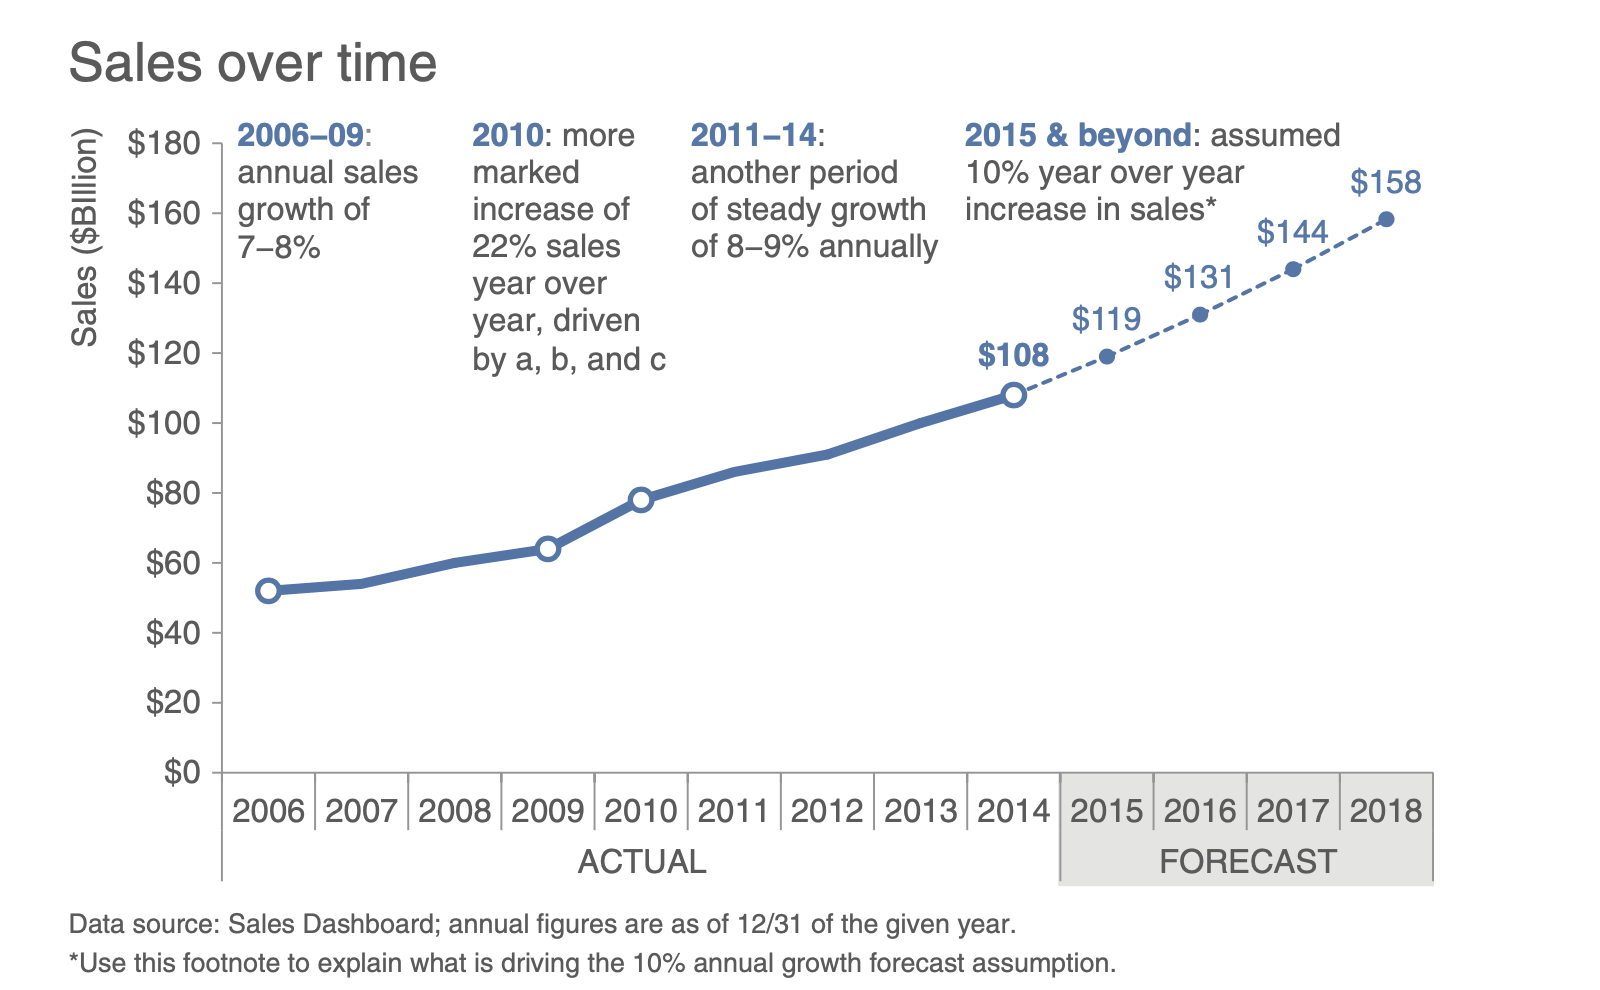 


---
## Design Principles - Part II: Part-to-Whole


### Pie Charts → Bar Charts

> 💡 **We established in Lecture 2 that pie charts require angle judgement — which humans do poorly. The default solution is a sorted horizontal bar chart. But what if your data has hierarchy? What if categories have sub-categories? This is where treemaps and sunbursts become genuinely useful**

**💡 When a bar chart is still better:**
- When ranking is the primary story
- When you have fewer than 15 categories
- When precise comparisons matter
*100% stacked bars — the bar alternative to pie for part-to-whole [ FIGURE 6.3 — p.156 ]*
> 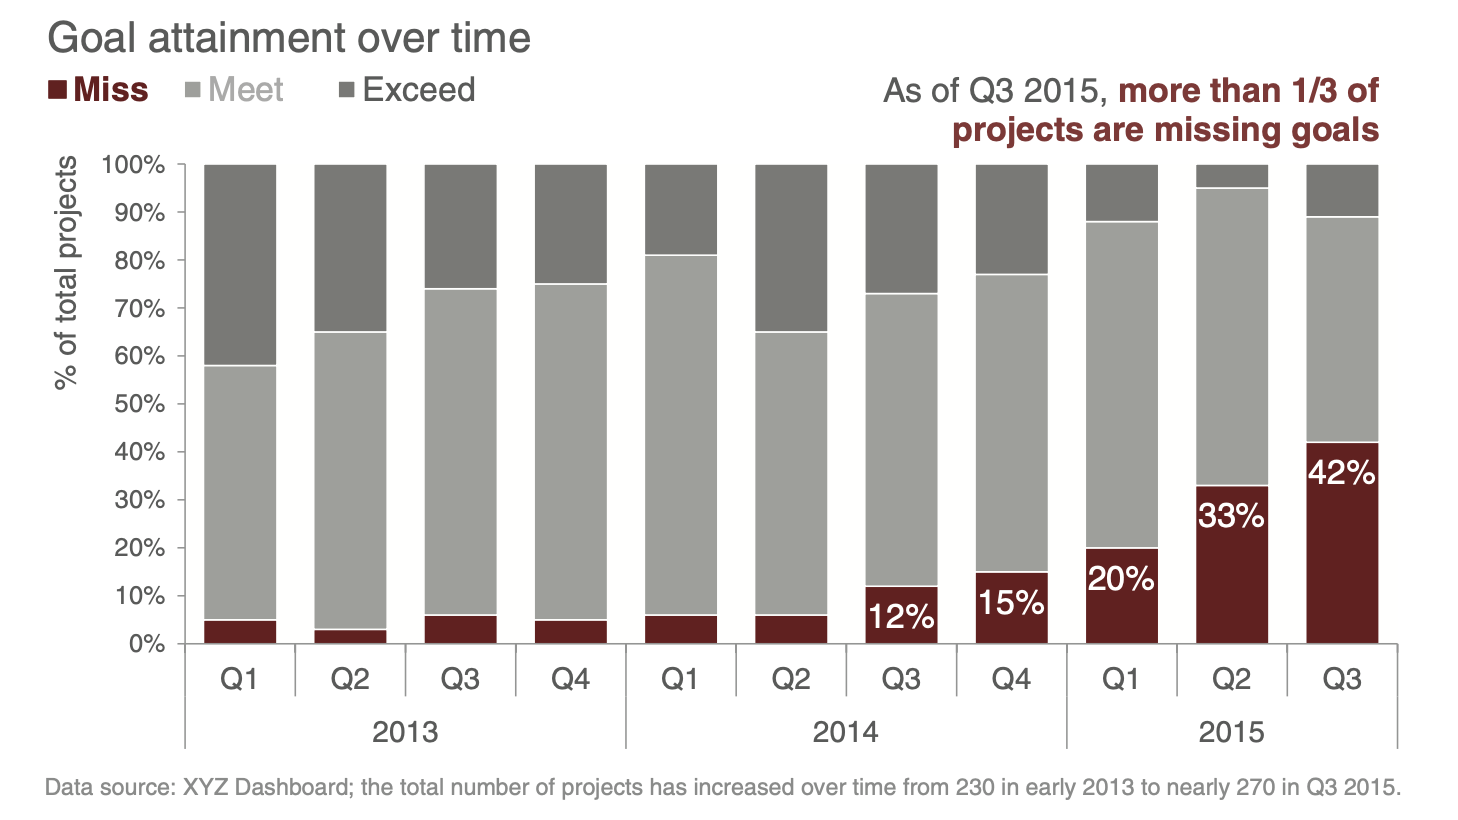 

*Horizontal stacked bars with three priority levels in shades of one colour [ FIGURE 6.5 — p.161 ]*
> 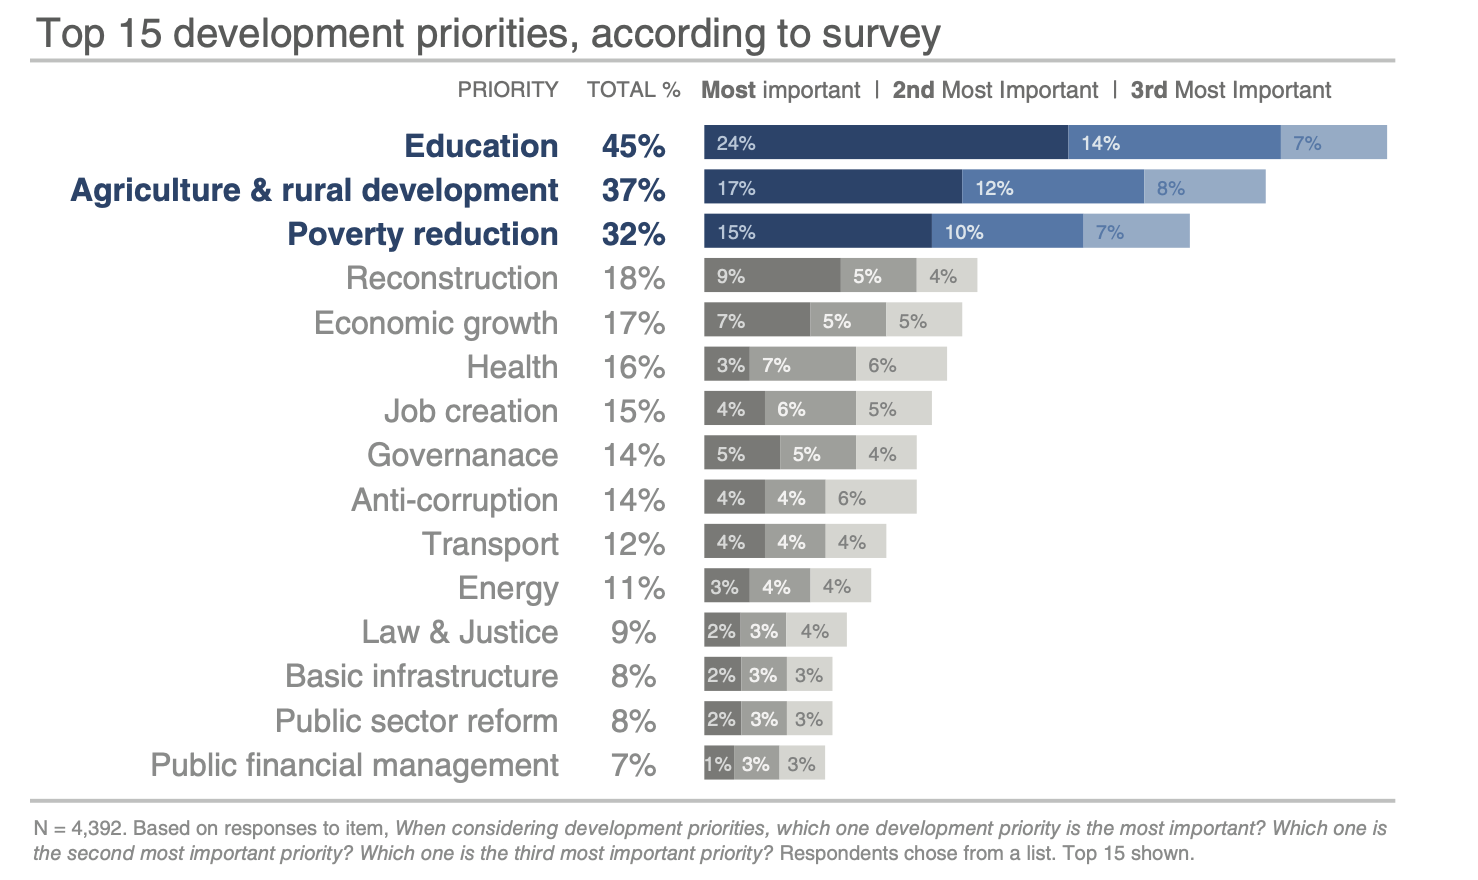 


**💡 When a treemap adds value:**
- When you have 15+ categories where area comparison is more useful than precise ranking
- When colour can encode a second metric (e.g. renewable share within each country)
- When space is limited and a bar chart would be very long

> 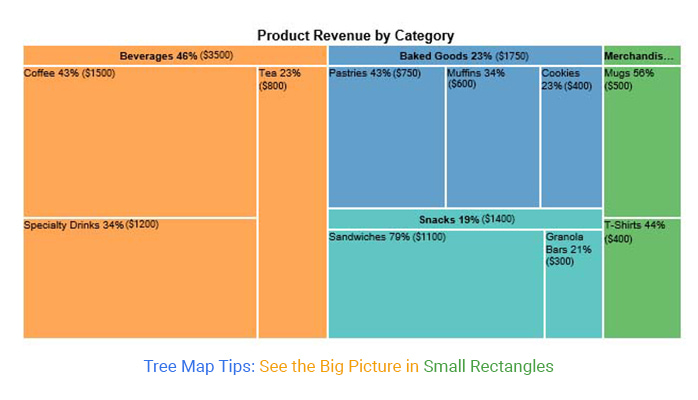

**💡 When a sunburst adds value:**
- When you have TWO levels of hierarchy and the nesting relationship IS the story
- Example: region → country → energy source

> 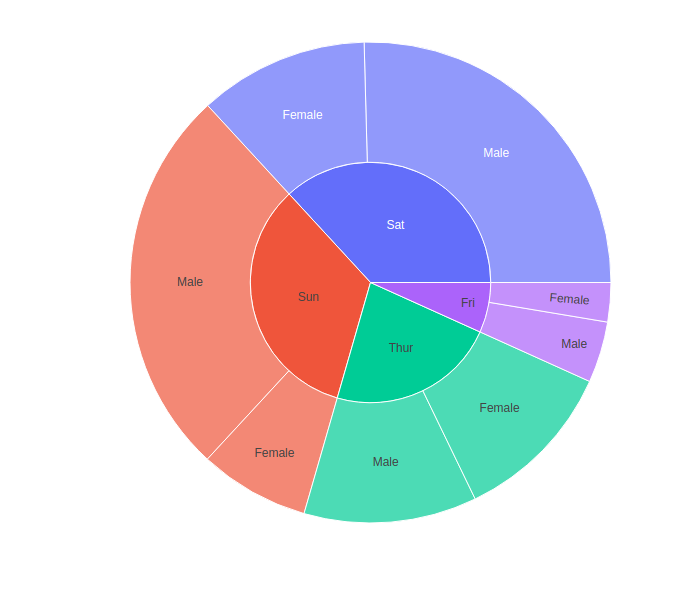

---
## Let's Code Some Examples 💻 



In [ ]:
import pandas as pd
import plotly.express as px


# Dataset: Global Energy Mix by Country and Source

df = pd.read_csv('../data/global_energy_mix.csv')
print(f"Loaded: {len(df)} rows")
print(df.head(10))


In [ ]:
df.info()

### Example 1 — Treemap: global energy mix

In [ ]:
# exploratory figure

fig = px.treemap(df, path=['Country', 'Source'], values='TWh',
                 title='Global Energy Mix', height=800)
fig.show()


In [ ]:
# Let's improve it

# Group sources into clean/dirty categories for colour
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

color_discrete_mapping = {
    'Fossil':     '#E07B39',   # orange: fossil fuels
    'Low-carbon': '#2E75B6',   # blue: nuclear + hydro
    'Renewable':  '#F5C842',   # yellow: wind, solar, other
}

# ── Step 1: Plotly Express base chart ─────────────────────────────────────────
fig = px.treemap(
    df,
    path=['Region', 'Country', 'Source'],
    values='TWh',                      # use TWh — sums correctly at every level
    color='Source_Type',
    color_discrete_map=color_discrete_mapping,
    labels={'Source_Type': 'Energy type', 'TWh': 'Energy (TWh)'},
    height=700, width=1300
)

# ── Step 2: Customisation ─────────────────────────────────────────────────────
fig.update_traces(
    textinfo='label+value',            # show label and TWh value — no percentages
    texttemplate='%{label}<br>%{value:,.0f} TWh',  # thousands separator, no decimals
    hovertemplate='<b>%{label}</b><br>%{value:,.0f} TWh<extra></extra>'
)

fig.update_layout(
    title='Fossil fuels still dominate globally — orange rectangles dwarf blue and yellow in most countries',
    font=dict(family='Arial', size=12),
    margin=dict(l=10, r=10, t=55, b=10),
    paper_bgcolor='white',
)

fig.data[0].marker.colors = [
    c if c in color_discrete_mapping.values() else '#DDDDDD'
    for c in fig.data[0].marker.colors
]

fig.show()

### Example 2 — Sunburst: hierarchy tells the nesting story

In [ ]:
tips = px.data.tips()

print(tips.info())
print(tips.head())

In [ ]:

# ── Data prep ─────────────────────────────────────────────────────────────────
# Count bills per group for male and female
df_sun = (
    tips.groupby(['day', 'time', 'sex'])
    .size()
    .reset_index(name='count')
)

df_sun.head(10)

In [ ]:
# exploratory

fig = px.sunburst(
    data_frame=df_sun,
    path=['day', 'time', 'sex'],    # hierarchy: day → meal time → sex
    values='count',                     # size of each segment = number of bills
    color='sex',                     # colour encodes sex
    labels={'count': 'Number of bills', 'sex': 'Sex'},
    title='Dinner dominates — and smokers are a consistent minority across all days',
    width=700, height=700
)

fig.show()

In [ ]:
# Let's make it better

# Colour mapping — red/blue for sex (note: not CVD-safe)
color_discrete_mapping = {
    'Male':   '#2E75B6',   # blue: male
    'Female': '#E63946',   # red: female
}

# ── Step 1: Plotly Express base chart ─────────────────────────────────────────
fig = px.sunburst(
    df_sun,
    path=['day', 'time', 'sex'],
    values='count',
    color='sex',
    color_discrete_map=color_discrete_mapping,
    labels={'count': 'Number of bills', 'sex': 'Sex'},
    title='Dinner dominates — and female patrons are a consistent minority across most days and times',
    height=600, width=600
)

# ── Step 2: Customisation ─────────────────────────────────────────────────────
fig.update_traces(
    textinfo='label+percent parent',
    hovertemplate='<b>%{label}</b><br>Bills: %{value}<br>%{percentParent:.0%} of %{parent}<extra></extra>',
    insidetextorientation='radial',
)

# Grey out parent nodes (day and time level) — replace any non-palette colour
fig.data[0].marker.colors = [
    c if c in color_discrete_mapping.values() else '#DDDDDD'
    for c in fig.data[0].marker.colors
]

fig.update_layout(
    font=dict(family='Arial', size=12),
    margin=dict(l=10, r=10, t=55, b=10),
    paper_bgcolor='white',
)

fig.show()

### Example 3 — When bars beat treemaps

In [ ]:

# Let's compare renewable TWh per country — treemap vs bar
renewable = df.loc[df['Source_Type'] == 'Renewable'].groupby('Country')['TWh'].sum().reset_index()
renewable = renewable.sort_values('TWh')

renewable['All'] = 'Renewables'   # dummy root node with a meaningful label

fig_tree = px.treemap(
    renewable,
    path=['All', 'Country'],       # All → Country
    values='TWh',
    color='TWh',
    color_continuous_scale='Greens',
    title='Renewable energy by country - Germany and UK are in the lead',
    labels={'TWh': 'Energy (TWh)'},
)
fig_tree.update_traces(
    texttemplate='%{label}<br>%{value:,.0f} TWh',
    hovertemplate='<b>%{label}</b><br>%{value:,.0f} TWh<extra></extra>',
    root_color='white',
)

fig_tree.show()

# Bar chart version
fig_bar = px.bar(
    renewable,
    x='TWh',
    y='Country',
    orientation='h',
    color='TWh',
    color_continuous_scale='Greens',
    title='Germany and UK lead on renewables',
    labels={'TWh': 'Renewable Energy (TWh)', 'Country': ''},
)
fig_bar.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    coloraxis_showscale=False,
)
fig_bar.update_xaxes(gridcolor='#EEEEEE')
fig_bar.update_yaxes(gridcolor='#EEEEEE')
fig_bar.show()

---
## Class Exercise 💪 💻


**Checklist:**
- Colour encodes a meaningful category 
- Insight title names the specific finding
- Consider: would a bar chart be clearer? If yes, use the bar chart
